# 01 — RNN từ nền tảng: trực giác, toán học và code

Notebook này xây dựng trực giác về **Recurrent Neural Network (RNN)** từ những ví dụ số nhỏ. Mục tiêu là hiểu RNN lưu thông tin theo thời gian như thế nào, tensor đi qua framework với shape gì, và vì sao gradient có thể biến mất hoặc bùng nổ.

Phạm vi của notebook:

- chỉ dùng dữ liệu giả lập rất nhỏ để học khái niệm;
- không đọc hai dataset của assignment;
- không train model dự báo cuối cùng;
- Vanilla RNN / `SimpleRNN` là trọng tâm, LSTM và GRU chỉ được giới thiệu như phần mở rộng.


## Thiết lập tái lập

Ta dùng `SEED = 42` cho Python, NumPy, PyTorch và TensorFlow/Keras. Seed giúp các ví dụ ngẫu nhiên trong **cùng môi trường** dễ lặp lại hơn, nhưng không bảo đảm kết quả bit-for-bit giống nhau giữa mọi framework, phiên bản thư viện hay phần cứng.


In [1]:
import os
import random
import sys

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

print(f"Python executable: {sys.executable}")
print(f"NumPy: {np.__version__} | PyTorch: {torch.__version__}")
print(f"TensorFlow: {tf.__version__} | Keras: {keras.__version__}")
print(f"PyTorch CUDA khả dụng: {torch.cuda.is_available()}")

Python executable: C:\Users\anhca\anaconda3\envs\rnn312\python.exe
NumPy: 2.5.3 | PyTorch: 2.14.0+cpu
TensorFlow: 2.21.0 | Keras: 3.15.1
PyTorch CUDA khả dụng: False


## 1. Sequence data là gì?

**Sequence data** là dữ liệu gồm các phần tử có thứ tự. Vị trí của một quan sát mang ý nghĩa, vì quan sát hiện tại thường liên quan đến những gì xảy ra trước đó.

- **Chứng khoán theo ngày:** giá ngày thứ Ba xuất hiện sau giá ngày thứ Hai; đảo thứ tự ngày sẽ phá vỡ diễn biến thị trường.
- **Hành vi khách hàng theo tuần:** chuỗi `[không mua, không mua, mua]` gợi ý hành vi vừa quay lại, khác với `[mua, không mua, không mua]` dù tổng số tuần mua hàng bằng nhau.
- **Text/token:** “mèo đuổi chuột” và “chuột đuổi mèo” có cùng token nhưng nghĩa khác do thứ tự.

Một phép tổng hợp không xét thứ tự như mean có thể cho cùng kết quả đối với hai chuỗi hoán vị, trong khi các biến thiên liên tiếp lại khác nhau.


In [2]:
sequence_a = np.array([1.0, 3.0, 2.0])
sequence_b = np.array([3.0, 1.0, 2.0])

print("Mean A, B:", sequence_a.mean(), sequence_b.mean())
print("Thay đổi liên tiếp của A:", np.diff(sequence_a))
print("Thay đổi liên tiếp của B:", np.diff(sequence_b))

Mean A, B: 2.0 2.0
Thay đổi liên tiếp của A: [ 2. -1.]
Thay đổi liên tiếp của B: [-2.  1.]


## 2. Vì sao Feed-Forward Neural Network không có memory?

Với một Feed-Forward Neural Network thông thường, mỗi thời điểm được xử lý như một ví dụ độc lập:

```text
x_t ──> NN ──> y_t
```

Mạng không tự biết `x_(t-1)` là gì nếu ta không chủ động ghép quá khứ vào input. Cùng một `x_t` sẽ tạo cùng output khi weights cố định, bất kể trước đó chuỗi đã diễn ra thế nào.

RNN thêm một đường truyền trạng thái:

```text
h_(t-1) ──┐
          ├──> RNN cell ──> h_t ──> y_t
x_t ──────┘
```

`h_(t-1)` là **hidden state**: một vector tóm tắt có học của quá khứ. Vì vậy dự đoán tại thời điểm `t` phụ thuộc cả input hiện tại lẫn ngữ cảnh trước đó.


## 3. RNN cell và hidden state

Một Vanilla RNN cell thường được viết:

$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$

và output tuyến tính tại thời điểm `t` có thể là:

$$
y_t = W_{hy}h_t + b_y
$$

| Ký hiệu       | Ý nghĩa                                                     |
| ------------- | ----------------------------------------------------------- |
| $x_t$         | vector input tại time step $t$                              |
| $h_{t-1}$     | hidden state từ bước trước; $h_0$ thường khởi tạo bằng zero |
| $h_t$         | hidden state mới sau khi kết hợp hiện tại và quá khứ        |
| $W_{xh}$      | weights nối input với hidden state                          |
| $W_{hh}$      | recurrent weights nối hidden state cũ với hidden state mới  |
| $b_h$         | bias của hidden state                                       |
| $\tanh$       | activation nén mỗi phần tử về khoảng $(-1, 1)$              |
| $W_{hy}, b_y$ | weights và bias biến hidden state thành output              |
| $y_t$         | output/logit/prediction tại time step $t$, tùy bài toán     |

Hidden state không phải một bản sao hoàn hảo của toàn bộ lịch sử. Nó là một biểu diễn có kích thước cố định mà mạng học để giữ thông tin hữu ích cho mục tiêu.


## 4. Manual RNN forward pass bằng NumPy

Ta dùng 3 time steps, mỗi input có 2 features, hidden state có 2 phần tử và output có 1 phần tử. Mọi ma trận đều được ghi tường minh để có thể theo dõi phép tính.


In [ ]:
X = np.array(
    [
        [1.0, 0.0],  # x1
        [0.0, 1.0],  # x2
        [1.0, 1.0],  # x3
    ]
)

W_xh = np.array(
    [
        [0.5, -0.4],
        [0.3, 0.8],
    ]
)
W_hh = np.array(
    [
        [0.2, 0.1],
        [-0.3, 0.4],
    ]
)
b_h = np.array([0.1, -0.1])
W_hy = np.array([[0.7, -0.5]])
b_y = np.array([0.05])

h = np.zeros(2)  # h0
hidden_states = []

for time_step, x_t in enumerate(X, start=1):
    pre_activation = W_xh @ x_t + W_hh @ h + b_h
    h = np.tanh(pre_activation)
    y_t = W_hy @ h + b_y
    hidden_states.append(h.copy())
    print(
        f"x{time_step}={x_t} -> "
        f"z{time_step}={np.round(pre_activation, 4)} -> "
        f"h{time_step}={np.round(h, 4)} -> "
        f"y{time_step}={np.round(y_t, 4)}"
    )

x1=[1. 0.] -> z1=[0.6 0.2] -> h1=[0.537  0.1974] -> y1=[0.3272]
x2=[0. 1.] -> z2=[-0.1729  0.6178] -> h2=[-0.1712  0.5496] -> y2=[-0.3446]
x3=[1. 1.] -> z3=[0.2207 1.2712] -> h3=[0.2172 0.8541] -> y3=[-0.225]


Kết quả cho thấy đường đi `x1 → h1`, `x2 → h2`, `x3 → h3`. Khi tính `h2`, vector `h1` đã tham gia; khi tính `h3`, vector `h2` tham gia. Đó là cơ chế memory cơ bản của RNN.

## 5. Weight sharing through time

Trong vòng lặp trên, ta **không tạo** `W_xh_step1`, `W_xh_step2`, ... Các biến `W_xh`, `W_hh`, `b_h` giống hệt nhau được tái sử dụng ở mọi time step.

Weight sharing có hai hệ quả quan trọng:

1. số parameters không tăng theo độ dài sequence;
2. cùng một quy tắc chuyển trạng thái được học và áp dụng ở mọi vị trí thời gian.

Nếu hidden size là $H$ và input size là $F$, riêng RNN cell có $H\times F + H\times H + H$ parameters, không phụ thuộc sequence dài 3 hay 300 bước.


In [4]:
input_size, hidden_size = W_xh.shape[1], W_hh.shape[0]
cell_parameters = W_xh.size + W_hh.size + b_h.size

print("W_xh dùng chung ở cả 3 bước:\n", W_xh)
print("W_hh dùng chung ở cả 3 bước:\n", W_hh)
print(f"Số parameters của cell: {cell_parameters}")
print(f"Không đổi khi sequence length = {len(X)}")

W_xh dùng chung ở cả 3 bước:
 [[ 0.5 -0.4]
 [ 0.3  0.8]]
W_hh dùng chung ở cả 3 bước:
 [[ 0.2  0.1]
 [-0.3  0.4]]
Số parameters của cell: 10
Không đổi khi sequence length = 3


## 6. RNN unrolling

**Unrolling** không tạo ra ba mạng khác nhau. Nó chỉ trải cùng một RNN cell theo trục thời gian để ta nhìn thấy luồng tính toán:

```text
             cùng W_xh, W_hh, b_h ở mọi bước

h0 ───────> [RNN cell] ──h1──> [RNN cell] ──h2──> [RNN cell] ──> h3
               ▲                  ▲                  ▲
               │                  │                  │
              x1                 x2                 x3
```

Sơ đồ unrolled cũng cho thấy vì sao thông tin và gradient phải đi qua một chuỗi phép biến đổi liên tiếp.


## 7. Sequence shapes

Một sequence đơn thường có shape:

$$
(\text{sequence\_length},\ \text{features})
$$

Khi ghép nhiều samples thành batch và dùng quy ước `batch_first=True`:

$$
(\text{batch\_size},\ \text{sequence\_length},\ \text{features})
$$

Trong A06:

- Stock: 32 samples × 30 ngày × 5 features → **`(32, 30, 5)`**.
- Customer: 32 samples × 8 tuần × 5 features → **`(32, 8, 5)`**.

Axis đầu chọn sample, axis giữa đi theo thời gian, axis cuối chứa các features quan sát tại một time step.


In [5]:
stock_batch = np.zeros((32, 30, 5))
customer_batch = np.zeros((32, 8, 5))

print("Stock batch shape:", stock_batch.shape)
print("Customer batch shape:", customer_batch.shape)
print("Một stock sequence:", stock_batch[0].shape)
print("Một stock time step:", stock_batch[0, 0].shape)

Stock batch shape: (32, 30, 5)
Customer batch shape: (32, 8, 5)
Một stock sequence: (30, 5)
Một stock time step: (5,)


## 8. Các pattern input/output

| Pattern      | Mô tả                             | Ví dụ                                                     |
| ------------ | --------------------------------- | --------------------------------------------------------- |
| one-to-one   | một input → một output            | phân loại một ảnh; không phải bài toán sequence điển hình |
| one-to-many  | một input → một sequence output   | tạo chuỗi caption từ một ảnh                              |
| many-to-one  | một sequence input → một output   | phân loại sentiment; dự đoán sau khi đọc toàn bộ cửa sổ   |
| many-to-many | một sequence input → nhiều output | gán nhãn mỗi token hoặc dịch chuỗi                        |

**A06 chủ yếu là many-to-one:**

- 8 tuần hành vi → một nhãn mua/không mua ở tuần kế tiếp;
- 30 ngày OHLCV → một giá Close ở ngày giao dịch kế tiếp.

Ta thường lấy hidden state cuối làm biểu diễn của toàn bộ cửa sổ, rồi đưa nó qua một output layer phù hợp với classification hoặc regression.


## 9. PyTorch RNN shape demo

Với `torch.nn.RNN(..., batch_first=True)`, input có shape `(batch, sequence, input_size)`.

- `output` chứa hidden state của **mọi time step** ở layer cuối: `(batch, sequence, hidden_size)`.
- `h_n` chứa hidden state cuối của từng layer và direction: `(num_layers × num_directions, batch, hidden_size)`.

Demo sau dùng một layer, một direction nên `output[:, -1, :]` bằng `h_n[0]`.


In [6]:
torch.manual_seed(SEED)

batch_size, sequence_length = 2, 3
input_size, hidden_size = 4, 5
x_torch = torch.randn(batch_size, sequence_length, input_size)

pytorch_rnn = torch.nn.RNN(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=1,
    batch_first=True,
    nonlinearity="tanh",
)
output, h_n = pytorch_rnn(x_torch)

print("input shape: ", tuple(x_torch.shape))
print("output shape:", tuple(output.shape))
print("h_n shape:   ", tuple(h_n.shape))
print("output cuối bằng h_n[0]:", torch.allclose(output[:, -1, :], h_n[0]))

input shape:  (2, 3, 4)
output shape: (2, 3, 5)
h_n shape:    (1, 2, 5)
output cuối bằng h_n[0]: True


`output` hữu ích khi cần output cho mỗi time step (many-to-many). Với many-to-one của A06, ta thường dùng hidden state cuối, sau đó nối một `Linear` layer để tạo logit classification hoặc giá trị regression.

## 10. Keras `SimpleRNN` shape demo

Keras mặc định nhận input `(batch, sequence, features)`.

- `return_sequences=False`: chỉ trả output của time step cuối, shape `(batch, units)`.
- `return_sequences=True`: trả output ở mọi time step, shape `(batch, sequence, units)`.
- `return_state=True`: trả thêm final hidden state.


In [7]:
tf.random.set_seed(SEED)
x_keras = tf.random.normal((2, 3, 4), seed=SEED)

keras_rnn_all = keras.layers.SimpleRNN(
    units=5,
    return_sequences=True,
    return_state=True,
)
sequence_output, final_state = keras_rnn_all(x_keras)

keras_rnn_last = keras.layers.SimpleRNN(
    units=5,
    return_sequences=False,
    return_state=True,
)
last_output, last_state = keras_rnn_last(x_keras)

print("input shape:           ", tuple(x_keras.shape))
print("return_sequences=True:", tuple(sequence_output.shape))
print("final_state shape:     ", tuple(final_state.shape))
print("return_sequences=False:", tuple(last_output.shape))
print("last_state shape:       ", tuple(last_state.shape))

input shape:            (2, 3, 4)
return_sequences=True: (2, 3, 5)
final_state shape:      (2, 5)
return_sequences=False: (2, 5)
last_state shape:        (2, 5)


Trong một `SimpleRNN` layer cụ thể, output cuối và final state biểu diễn cùng time step cuối. Hai layer trong demo được khởi tạo độc lập, nên ta chỉ so sánh **shape**, không so sánh giá trị giữa chúng.

## 11. Loss và trực giác training

Training nối các bước sau thành một vòng lặp:

```text
input sequence → RNN → prediction → loss so với target
                              │
                              └─ backpropagation → gradient → optimizer cập nhật weights
```

- Customer classification có thể dùng **binary cross-entropy** trên logit/xác suất mua hàng.
- Stock regression có thể dùng **MSE** hoặc MAE giữa giá dự đoán và giá thật.

Loss là một số vô hướng đo mức sai. Backpropagation tính đạo hàm của loss theo từng parameter; optimizer dịch chuyển parameters theo hướng làm loss giảm. Các số dưới đây chỉ là ví dụ toán học nhỏ, không phải kết quả thực nghiệm của A06.


In [ ]:
labels = np.array([1.0, 0.0])
probabilities = np.array([0.8, 0.3])
binary_cross_entropy = -np.mean(
    labels * np.log(probabilities) + (1 - labels) * np.log(1 - probabilities)
)

close_true = np.array([102.0, 104.0])
close_pred = np.array([101.5, 105.0])
mean_squared_error = np.mean((close_true - close_pred) ** 2)

print(f"Toy binary cross-entropy: {binary_cross_entropy:.4f}")
print(f"Toy mean squared error:   {mean_squared_error:.4f}")

Toy binary cross-entropy: 0.2899
Toy mean squared error:   0.6250


## 12. Backpropagation Through Time — BPTT

**BPTT** là backpropagation áp dụng lên RNN đã unroll. Loss ở cuối sequence có thể phụ thuộc `h3`; `h3` phụ thuộc `h2`; `h2` lại phụ thuộc `h1`. Vì vậy gradient đi ngược qua các time steps:

```text
forward:   h0 → h1 → h2 → h3 → loss
backward:       ←     ←     ←
```

Do weights được chia sẻ, gradient đóng góp từ nhiều time steps được cộng vào cùng `W_xh` và `W_hh`. BPTT giúp RNN học ảnh hưởng của quá khứ, nhưng đường gradient càng dài thì càng dễ gặp vanishing hoặc exploding gradient.


## 13. Vanishing gradient

Theo chain rule, gradient qua nhiều bước chứa tích của nhiều đạo hàm/Jacobian. Nếu các hệ số hiệu dụng thường nhỏ hơn 1, tích giảm rất nhanh. Ví dụ đơn giản: $0.5^{20} \approx 9.54\times10^{-7}$.

Khi gradient từ xa gần bằng zero, RNN khó học quan hệ dài hạn: tín hiệu ở cuối chuỗi hầu như không cập nhật được cách xử lý ở đầu chuỗi. Đạo hàm của `tanh` cũng nhỏ khi activation rơi vào vùng bão hòa gần -1 hoặc 1.

## 14. Exploding gradient

Nếu các hệ số hiệu dụng thường lớn hơn 1, tích có thể tăng rất nhanh. Ví dụ $1.5^{20}$ lớn hơn 3.000. Gradient quá lớn làm update thiếu ổn định, loss dao động hoặc xuất hiện `NaN`.

Đồ thị sau minh họa phép nhân lặp; đây không phải loss curve của một model.


0.5^20 = 0.00000095
1.5^20 = 3325.2567


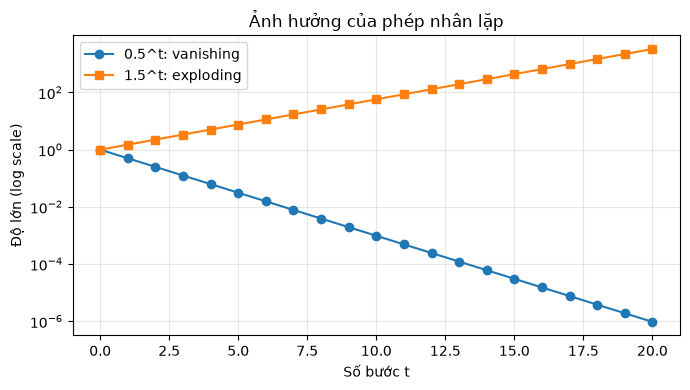

In [ ]:
steps = np.arange(0, 21)
shrinking = 0.5**steps
growing = 1.5**steps

print(f"0.5^20 = {shrinking[-1]:.8f}")
print(f"1.5^20 = {growing[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(steps, shrinking, marker="o", label="0.5^t: vanishing")
ax.semilogy(steps, growing, marker="s", label="1.5^t: exploding")
ax.set(
    title="Ảnh hưởng của phép nhân lặp", xlabel="Số bước t", ylabel="Độ lớn (log scale)"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 15. Gradient clipping

**Gradient clipping** giới hạn độ lớn gradient trước khi optimizer cập nhật weights. Với clipping theo norm, nếu norm tổng vượt ngưỡng, toàn bộ gradient được co lại nhưng giữ hướng tương đối.

Clipping hữu ích cho exploding gradient, nhưng không giải quyết tận gốc vanishing gradient và không thay thế việc chọn learning rate phù hợp. Trong PyTorch có `torch.nn.utils.clip_grad_norm_`; Keras optimizers có tham số như `clipnorm`.


In [10]:
toy_parameter = torch.nn.Parameter(torch.zeros(2))
toy_parameter.grad = torch.tensor([30.0, 40.0])  # norm = 50

norm_before = toy_parameter.grad.norm().item()
torch.nn.utils.clip_grad_norm_([toy_parameter], max_norm=5.0)
norm_after = toy_parameter.grad.norm().item()

print(f"Gradient norm trước clipping: {norm_before:.1f}")
print(f"Gradient sau clipping: {toy_parameter.grad.tolist()}")
print(f"Gradient norm sau clipping:   {norm_after:.1f}")

Gradient norm trước clipping: 50.0
Gradient sau clipping: [2.999999761581421, 3.999999761581421]
Gradient norm sau clipping:   5.0


## 16. Động lực của LSTM

**LSTM** được thiết kế để tạo đường truyền thông tin dài hạn thuận lợi hơn Vanilla RNN. Ngoài hidden state $h_t$, LSTM có **cell state** $c_t$, giống một “băng chuyền” bộ nhớ được điều khiển bằng gates:

- **forget gate:** quyết định phần nào của $c_{t-1}$ nên giữ hoặc quên;
- **input gate:** quyết định lượng thông tin mới được ghi vào cell state;
- **output gate:** quyết định phần nào của cell state được biểu lộ thành hidden state $h_t$.

Gates thường dùng sigmoid nên cho hệ số từ 0 đến 1. Cơ chế cộng/cập nhật cell state giúp gradient có đường đi ổn định hơn, dù LSTM vẫn không miễn nhiễm hoàn toàn với khó khăn khi training.

Notebook này không triển khai LSTM vì mục tiêu là hiểu Vanilla RNN trước.


## 17. Động lực của GRU

**GRU** cũng dùng gates nhưng gọn hơn LSTM và không tách riêng cell state:

- **update gate:** cân bằng giữa việc giữ hidden state cũ và nhận candidate state mới;
- **reset gate:** quyết định quá khứ ảnh hưởng bao nhiêu khi tạo candidate state.

GRU thường có ít parameters hơn LSTM, vì vậy có thể train nhanh hơn trong một số bài toán. Tuy nhiên không có quy tắc tuyệt đối rằng GRU hay LSTM luôn tốt hơn; lựa chọn cần dựa trên validation công bằng.


## 18. So sánh RNN, LSTM và GRU

| Tiêu chí           | Vanilla RNN             | LSTM                      | GRU                        |
| ------------------ | ----------------------- | ------------------------- | -------------------------- |
| Trạng thái chính   | hidden state            | hidden state + cell state | hidden state               |
| Gates              | không                   | forget, input, output     | update, reset              |
| Số parameters      | ít nhất                 | nhiều nhất                | thường ở giữa              |
| Quan hệ dài hạn    | khó hơn                 | thường tốt hơn            | thường tốt hơn Vanilla RNN |
| Tốc độ/độ đơn giản | đơn giản, dễ học cơ chế | phức tạp hơn              | gọn hơn LSTM               |
| Vai trò trong A06  | baseline chính          | extension tùy chọn        | extension tùy chọn         |

Bảng này mô tả xu hướng kiến trúc, không phải cam kết về độ chính xác trên mọi dataset.
